___
# <font color= #003366> **Variational Autoencoder for T-Shirt Image Generation** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 1: </Strong>  <font color="blue">`Autoencoders` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

<img src="https://www.cs.us.es/~fsancho/Blog/posts/img/vae3.png" width="800">

## <font color=  #003366> **Variational Autoencoder**</font>

A Variational Autoencoder, or VAE, is a generative model from deep learning that can learn to compress images into a smaller representation and then recreate them. In this project, we are using a VAE to generate new images by learning patterns from our 297 original images, so it can create images that look similar but are not exactly the same.

## <font color=  #003366> **Following Next Steps**</font>

Following the analysis of the second experiment in the project, different adjustments were made to improve the VAE and the image generation, which will be explained in this notebook.

As said in the experiment two, it is important to note that the images in the dataset were not only increased, but a cleanup was also performed. T-shirts with very light colors were removed because, having a white background, they are not very visible and are harder to detect. In addition to this cleanup, new images were added to the dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We connect to Google Drive so we can run the notebook using Colab, so we can use GPU and so the experiments run faster.

## <font color=  #003366> **Required Libraries**</font>

In [2]:
import os
import numpy as np
import json
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from sklearn.metrics import mean_squared_error

folder = "/content/drive/MyDrive/deep_learning_project1/preprocesado"

## <font color=  #003366> **Set Seed**</font>

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

os.environ['PYTHONHASHSEED'] = str(seed)

We fix the seed to ensure reproducibility, which we didn't do in the first experiments

## <font color=  #003366> **Data Loading**</font>

In [4]:
def load_images(folder):
    images = []
    for file in os.listdir(folder):
        if file.endswith((".jpg", ".jpeg", ".png")):
            img = load_img(os.path.join(folder, file))
            img = img_to_array(img)
            images.append(img)
    return np.array(images, dtype="uint8")

X = load_images(folder)
print("Number of images:", len(X))
print("Shape:", X.shape)

Number of images: 686
Shape: (686, 128, 128, 3)


Following the steps of the first experiment in the project and analyzing the results of the generated images, we decided to add more images to the dataset. The dataset increased from 293 images to 686 images of 128x128 pixels. The function to load the images remains the same as in the first experiment of the project.

This function iterates through the dataset folder and loads all images with valid extensions (.jpg, .jpeg, .png).

Each image is:
- Loaded as RGB
- Converted to a NumPy array
- Stored in a list
- Converted into a NumPy array of shape:
(686, 128, 128, 3)

Which means that we have 686 total images, of 128x128 in RGB channels

## <font color=  #003366> **Normalization**</font>

In [5]:
X = X.astype("float32") / 255.0

We convert pixel values from integers in the range [0, 255] to floating values in the range [0, 1].

This is necessary because:

- It improves numerical stability.
- It accelerates convergence during optimization.
- It prevents large gradient updates caused by large input values.

The normalization is performed by dividing each pixel value by 255.

## <font color=  #003366> **Train/Test**</font>

In [6]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (548, 128, 128, 3)
Test: (138, 128, 128, 3)


The dataset is split into 80% training and 20% testing, so we can train and evaluate.

## <font color=  #003366> **Visualizations Original Images**</font>


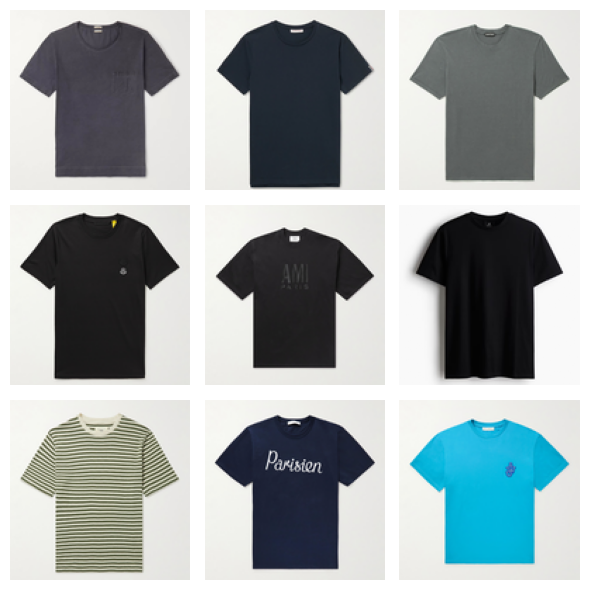

In [7]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


Here we can see some visualizations of the original images in the dataset, we can see that we have different colors, sizes and designs.

## <font color=  #003366> **Data Augmentation**</font>

In [8]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1
)

To improve model robustness, small random transformations are applied to the training images:

- Rotation (±5 degrees)
- Width and height shift (±5%)
- Zoom (±5%)
- Horizontal flip

## <font color=  #003366> **Data Augmentation Visualization**</font>

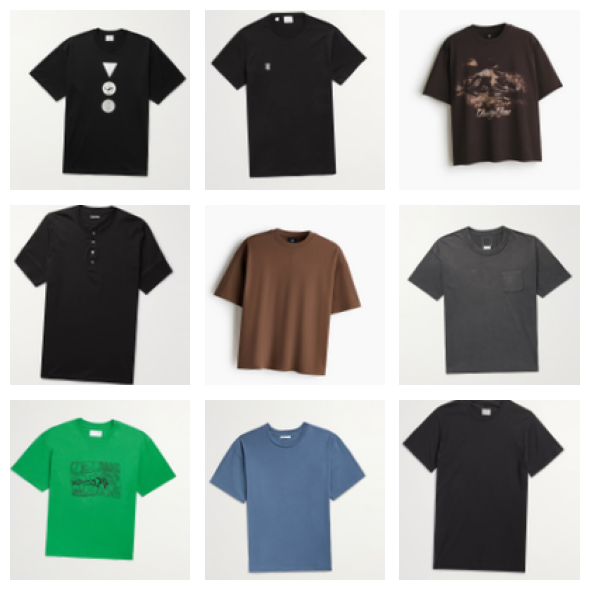

In [9]:
X_batch = next(datagen.flow(X_train, batch_size=9))

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_batch[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

Here we can see come visualizations of the data augmentation with different zooms, rotations, etc.

In [10]:
batch_size = 32

train_generator = datagen.flow(
    X_train,
    X_train,
    batch_size=batch_size,
    subset='training',
    shuffle=True,
    seed=seed
)

validation_generator = datagen.flow(
    X_train,
    X_train,
    batch_size=batch_size,
    subset='validation',
    shuffle=False,
    seed=seed
)

## <font color=  #003366> **Defining the Latent Space**</font>

In [11]:
latent_dim = 128

Here, we define the dimensionality of the latent space.

The latent dimension controls how much compressed information the model can store about each image.

A smaller latent dimension forces stronger compression, while a larger dimension allows more detailed representations.

Unlike the first experiment where we used a latent dimension of 32, this time we used a latent dimension of 128, which is the same used in the second experiment. We decided this because the dataset is now larger and the image resolution increased from 64×64 to 128×128

## <font color=  #003366> **Sampling Layer (Reparameterization Trick)**</font>

In [41]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        # KL Divergence
        beta = 0.001

        kl_loss = beta * (-0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        ))

        self.add_loss(kl_loss)
        return z

This is what makes the model a Variational Autoencoder.

Instead of encoding into a single vector, the encoder outputs:
- z_mean
- z_log_var

These define a Gaussian distribution.

This custom layer implements the reparameterization trick, which is a key component of Variational Autoencoders.

Instead of directly sampling from a normal distribution, we compute:

z = μ + σ * ε

Where:
- μ is the latent mean
- σ is derived from the log variance
- ε is sampled from a standard normal distribution

This formulation allows backpropagation through the sampling process.

Additionally, this layer computes and adds the KL Divergence loss, which regularizes the latent space to follow a normal distribution, which enables meaningful sampling

In the second experiment, we introduced a beta parameter of 0.005 in the KL divergence term:

In this experiment the beta will be: beta = 0.001

In a Variational Autoencoder, the total loss has two parts:
1. Reconstruction loss (how well the image is reconstructed)
2. KL divergence loss (how close the latent space is to a normal distribution)

The KL divergence forces the latent space to follow a normal distribution, which makes sampling possible and keeps the space structured.

The beta parameter controls how strong this regularization is.

Introducing beta allows better control over the trade-off between reconstruction and regularization. This provides more flexibility and helps improve image diversity compared to the first experiment.

We are trying to test with different beta values ​​to see if there are any improvements

## <font color=  #003366> **Encoder**</font>

In [42]:
encoder_inputs = layers.Input(shape=(128, 128, 3))

x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, z, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32768)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  8,388,864 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 128)       │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,547,904 (32.61 MB)

 Trainable params: 8,547,904 (32.61 MB)

 Non-trainable params: 0 (0.00 B)

The encoder is responsible for compressing the input image into a smaller latent representation.
The original image has size 128×128×3 (49,152 values), and the encoder reduces it step by step until it becomes a 128 dimensional latent vector.

The encoder has:
- 3 convolutional layers
- 3 max-pooling layers
- 1 flatten layer
- 1 dense hidden layer
- 2 dense layers to produce the latent variables (z_mean and z_log_var)

Each convolution layer extracts visual features from the image, such as edges, shapes, and patterns like sleeves or collars. As we go deeper into the network, the number of filters increases (32 → 64 → 128), allowing the model to learn more complex features.

MaxPooling layers reduce the spatial size of the image (128×128 → 64×64 → 32×32 → 16×16). This helps reduce computation and forces the network to keep only the most important information.

After the convolution layers, the feature maps are flattened into a vector and passed through a dense layer. This dense layer helps combine all extracted features before compressing them into the latent space.

Instead of producing a single encoding, the encoder learns a probabilistic latent representation defined by two vectors:
- z_mean, which represents the center of the latent distribution
- z_log_var, which represents the variance

A latent vector is then sampled from this distribution, forming the bottleneck of the model and representing a compressed version of the image.

This means the encoder reduces 49,152 values into only 128 values, achieving strong dimensionality reduction.

Compared to Experiment 1, the encoder is now capable of learning:
- more detailed structures
- better color representations
- higher variability between samples

## <font color=  #003366> **Decoder**</font>

In [43]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(16 * 16 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((16, 16, 128))(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32768)          │     4,227,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,467,779 (17.04 MB)

 Trainable params: 4,467,779 (17.04 MB)

 Non-trainable params: 0 (0.00 B)

The decoder does the opposite operation of the encoder. It takes the 128-dimensional latent vector sampled from the latent space and reconstructs the image back to its original size (128×128×3).

The decoder has:
- 1 dense layer
- 1 reshape layer
- 3 convolutional layers
- 3 upsampling layers
- 1 final convolution layer with sigmoid activation

First, the latent vector is expanded using a dense layer and reshaped into a small feature map (16×16×128). Then, the model gradually increases the spatial resolution using upsampling layers (16×16 → 32×32 → 64×64 → 128×128).

Convolution layers refine the image at each stage and help reconstruct details.

The final layer uses sigmoid activation because the images were normalized to values between 0 and 1.

## <font color=  #003366> **Variational Autoencoder Model**</font>

In [44]:
outputs = decoder(encoder(encoder_inputs))
vae = Model(encoder_inputs, outputs, name="VAE_Tshirts")

In this step, we connect the encoder and decoder to form the full VAE model.

The encoder compresses the image into a latent distribution.
A latent sample is drawn using the sampling layer.
The decoder reconstructs the image from that sample.

The KL divergence loss is automatically added during the sampling process.

## <font color=  #003366> **Model Compilation**</font>

In [45]:
vae.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.MeanSquaredError(),
    metrics=["mse"]
)

The model is compiled using the Adam optimizer.

We use Mean Squared Error (MSE) as the reconstruction loss.

The total loss of the VAE is composed of:

- Reconstruction Loss (MSE)
- KL Divergence (added inside the sampling layer)

This combination ensures both accurate reconstruction and a well-structured latent space.

## <font color=  #003366> **Model Training**</font>

In [46]:
history = vae.fit(
    train_generator,
    epochs=150,
    batch_size=32,
    validation_data = validation_generator
)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 590ms/step - loss: 0.1032 - mse: 0.1020 - val_loss: 0.0480 - val_mse: 0.0474
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - loss: 0.0469 - mse: 0.0466 - val_loss: 0.0356 - val_mse: 0.0354
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - loss: 0.0359 - mse: 0.0356 - val_loss: 0.0282 - val_mse: 0.0275
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - loss: 0.0285 - mse: 0.0279 - val_loss: 0.0259 - val_mse: 0.0253
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - loss: 0.0249 - mse: 0.0242 - val_loss: 0.0236 - val_mse: 0.0228
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - loss: 0.0237 - mse: 0.0229 - val_loss: 0.0223 - val_mse: 0.0215
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - loss: 0.0224 - mse: 0.0216 - val_loss: 0.0218 - val_mse: 0.0210
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 0.0225 - mse: 0.0218 - val_loss: 0.0213 - val_mse: 0.0205
Epoch 9/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms

In this experiment, the training process differs from the first and second experiment because the model is trained using an ImageDataGenerator instead of directly feeding the original images.

Additionally, the number of training epochs was increased from 50 epochs in Experiment 1 to 100 epochs in this experiment. Since augmented images introduce more variability, additional training time allows the model to better learn the distribution of the data and stabilize both reconstruction and KL losses.

As a result, the model is exposed to a better training process, encouraging the Variational Autoencoder to learn a smoother and more representative latent space.

## <font color=  #003366> **Loss Visualization**</font>

In the second experiment, the training analysis was improved by separating and visualizing each component of the loss function individually, unlike Experiment 1 where only the total loss was monitored.

A Variational Autoencoder optimizes two objectives simultaneously:
- Reconstruction Loss (MSE) which measures how well the model rebuilds the input image.
- KL Divergence Loss which regularizes the latent space by forcing it to follow a normal distribution.
- Total Loss — combination of both components.

Plotting these losses separately allows a deeper understanding of how the model learns and whether there is a balance between reconstruction quality and latent space regularization.

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])


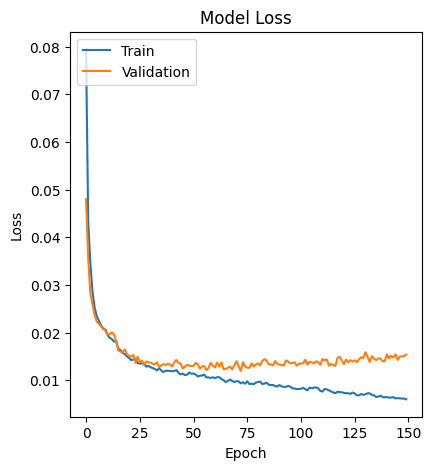

In [47]:
def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

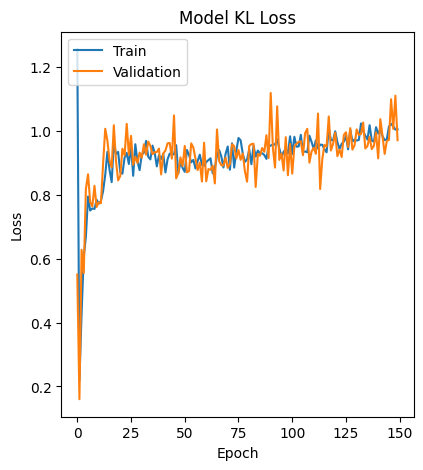

In [48]:
beta = 0.001

total_train = np.array(history.history["loss"])
recon_train = np.array(history.history["mse"])

total_val = np.array(history.history["val_loss"])
recon_val = np.array(history.history["val_mse"])

kl_train = (total_train - recon_train) / beta
kl_val = (total_val - recon_val) / beta

def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(kl_train, label="Train KL")
    plt.plot(kl_val, label="Val KL")
    plt.title('Model KL Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_history(history)

dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])


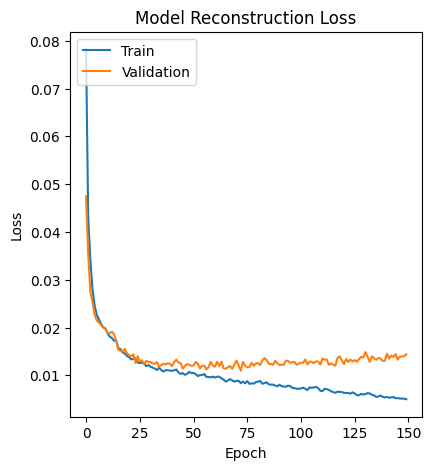

In [49]:
def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history["mse"], label="Train Reconstruction")
    plt.plot(history.history["val_mse"], label="Val Reconstruction")
    plt.title('Model Reconstruction Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

## <font color=  #003366> **Image Reconstruction**</font>

In [50]:
reconstructed = vae.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step


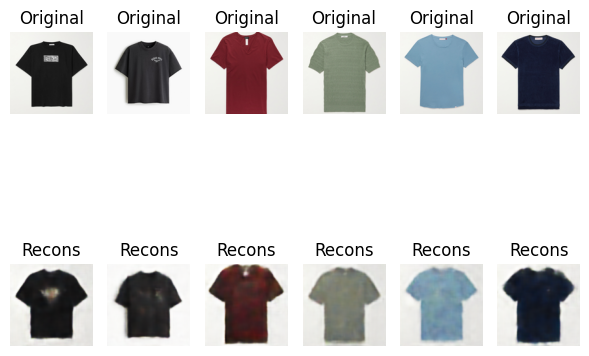

In [ ]:
import matplotlib.pyplot as plt

n = 6  

plt.figure(figsize=(6,6))

for i in range(n):

    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i])
    plt.title("Recons")
    plt.axis("off")

plt.tight_layout()
plt.show()

With this visualization we can see the reconstructed images.

## <font color=  #003366> **Metrics**</font>

To evaluate the performance of the Variational Autoencoder, two reconstruction metrics were used: Mean Squared Error (MSE) and Structural Similarity Index (SSIM). These metrics measure how similar the reconstructed images are to the original input images.

In [52]:
mse = np.mean((X_test - reconstructed) ** 2)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.01430076


An MSE value of 0.0143 is relatively low considering that:
- images were normalized between 0 and 1
- the model reconstructs complex colored t-shirts images
- the VAE introduces randomness because of the probabilistic sampling

This means:
- The reconstructed images are very close to the originals at the pixel level.
- The model successfully learned the main visual structure of the shirts.

Compared to Experiment 1 (higher MSE), this indicates a clear improvement in reconstruction quality.

In [53]:
ssim_values = tf.image.ssim(
    X_test,
    reconstructed,
    max_val=1.0
)

mean_ssim = tf.reduce_mean(ssim_values).numpy()
print("Mean SSIM:", mean_ssim)

Mean SSIM: 0.77301353


Unlike MSE, SSIM evaluates perceptual similarity, meaning how similar two images look to the human eye.

It compares:
- luminance (brightness)
- contrast
- edges and shapes

SSIM values range from:
- **1.0**: identical images
- **0**: no structural similarity

A mean SSIM of **0.77** indicates:

- High structural similarity between original and reconstructed images.
- The model preserves important visual structures such as:
  - shirt silhouettes
  - shapes

With both metrics, the results suggest that:

- The model achieves good numerical reconstruction (low MSE).
- The reconstructed images remain visually recognizable and structurally consistent (high SSIM).

This confirms that the VAE learned meaningful latent representations rather than simply memorizing pixel values.

## <font color=  #003366> **Image Generation**</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


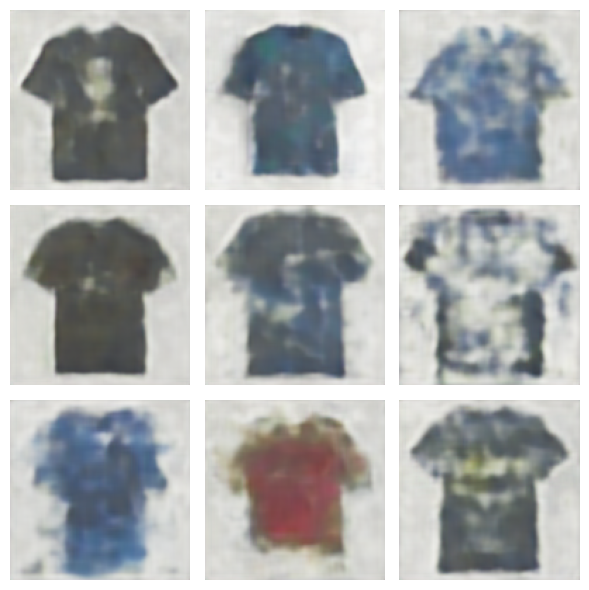

In [74]:
random_latent_vectors = np.random.normal(size=(9, latent_dim))
generated_images = decoder.predict(random_latent_vectors)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


In Experiment 3, reconstructed images show greater diversity in color, size, and shape compared to Experiment 1, but they don't seem better than Experiment 2. The higher latent dimension and data augmentation improved the model’s ability to capture structural and visual details. As a result, reconstructions are more defined and less repetitive, indicating a better learned latent representation.

## <font color=  #003366> **Save the generated images**</font>

In [75]:
os.makedirs("/content/drive/MyDrive/generated_samples", exist_ok=True)

for i in range(9):
    img = (generated_images[i] * 255).astype("uint8")
    plt.imsave(f"/content/drive/MyDrive/generated_samples/generated_{i}.png", img)

We decided to save the images generated so we can analyze them more clearly and to have the evidence of the generation

## <font color=  #003366> **Save final model**</font>

In [28]:
vae.save("vae_model_final.keras")

In [29]:
with open("history_bueno.json", "w") as f:
    json.dump(history.history, f)

# <font color=  #003366> **Summary of Improvements in Experiment 3**</font>

The third experiment was designed as an improved version of the secind experiment of the  Variational Autoencoder, incorporating several methodological and architectural improvemnets based on the observations obtained in Experiment 2.

While the second experiment successfully reconstructed shirt silhouettes, with color diversity and variability. We wanted to try another experiment to see if we could get better results. Therefore, multiple changes were introduced to improve representation capacity, reconstruction quality, and generative performance.


## <font color=  #003366> **Data Augmentation**</font>

To increase variability and reduce overfitting, **data augmentation** was introduced using small transformations:

- slight rotations
- horizontal shifts
- vertical shifts
- zoom variations
- horizontal flipping

This allowed the model to observe multiple variations of the same cloth without collecting additional real data, improving generalization and robustness.


## <font color=  #003366> **A Different Beta value**</font>

A β parameter was introduced in the Sampling class in experiment 2 to control the influence of the KL divergence term:

$$
\text{Loss} = \text{Reconstruction Loss} + \beta \cdot \text{KL Loss}
$$

This modification balances:

- reconstruction accuracy
- latent space regularization

- β = 0.001  


## <font color=  #003366> **Improved Loss Analysis**</font>

Unlike Experiment 1 and 2 , where only total loss was analyzed, Experiment 3 separates and visualizes:

- Total Loss
- Reconstruction Loss (MSE)
- KL Divergence Loss

This separation provides deeper insight into training dynamics and helps understand how each component contributes to model learning.

The loss curves showed stable convergence without strong oscillations, indicating consistent optimization.


## <font color=  #003366> **Training Improvements**</font>

Training duration was extended:

- Experiment 2: **50 epochs**
- Experiment 3: **150 epochs**

The increased dataset size and model complexity required longer training to allow proper convergence and feature learning.


## <font color=  #003366> **Generated Image Saving**</font>

Generated samples were automatically saved during experimentation. This enables:

- reproducibility
- qualitative comparison across experiments
- visual documentation of model progress

Saving generated outputs helps track improvements in generative quality.


## <font color=  #003366> **Additional Evaluation Metric: SSIM**</font>

Besides MSE, the **Structural Similarity Index (SSIM)** was incorporated to evaluate perceptual similarity between original and reconstructed images.

This metric complements pixel-based evaluation by measuring structural and visual consistency closer to human perception.


## <font color=  #003366> **Overall Improvement Summary**</font>


Compared to Experiment 1 and 2, the third experiment introduced improvements in:

- Dataset size and resolution
- Data augmentation
- Another beta β-VAE
- Training duration
- Loss analysis visualization
- Quantitative evaluation metrics
- Output reproducibility

These modifications resulted in reconstructions with improved color diversity, structural variation, and overall visual realism.

## <font color=  #003366> **Next Steps**</font>

A different beta value will be tested to analyze whether the generated images are better, as well as different epoch values ​​to visualize if there are improvements.